# Прогноз отмены бронирования в сети отелей

Проект посвящен задаче бинарной классификации: нужно предсказать, отменит ли клиент бронирование номера.  
Если модель считает бронь рискованной, клиенту предлагают внести депозит. Это должно снизить убытки от отмен.


## Цель проекта

1. Изучить данные о бронированиях и найти признаки, связанные с отменой.
2. Сравнить несколько моделей классификации по метрике `ROC-AUC`.
3. Выбрать лучшую модель и проверить ее на тестовой выборке.
4. Оценить, как использование модели влияет на убытки отеля на тестовом периоде.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## Загрузка данных

Ноутбук ищет файлы `hotel_train.csv` и `hotel_test.csv` в текущей папке проекта.  
При необходимости можно положить их рядом с ноутбуком или в корень репозитория.


In [2]:
PROJECT_ROOT = Path.cwd()

TRAIN_CANDIDATES = [
    PROJECT_ROOT / "data" / "hotel_train.csv",
    PROJECT_ROOT.parent / "data" / "hotel_train.csv",
    PROJECT_ROOT / "hotel_train.csv",
    PROJECT_ROOT.parent / "hotel_train.csv",
]
TEST_CANDIDATES = [
    PROJECT_ROOT / "data" / "hotel_test.csv",
    PROJECT_ROOT.parent / "data" / "hotel_test.csv",
    PROJECT_ROOT / "hotel_test.csv",
    PROJECT_ROOT.parent / "hotel_test.csv",
]

for candidate in TRAIN_CANDIDATES:
    if candidate.exists():
        TRAIN_PATH = candidate
        break
else:
    raise FileNotFoundError("Файл hotel_train.csv не найден.")

for candidate in TEST_CANDIDATES:
    if candidate.exists():
        TEST_PATH = candidate
        break
else:
    raise FileNotFoundError("Файл hotel_test.csv не найден.")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

for df in (train, test):
    df["reserved_room_type"] = df["reserved_room_type"].str.strip()

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train shape: (65229, 25)
Test shape: (32412, 25)


In [3]:
train.head()

,id,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,total_nights
0,0,0,7.0,2015,July,27,1,0,1,1.0,...,0,0,0,A,0,0,Transient,0,0,1
1,1,0,14.0,2015,July,27,1,0,2,2.0,...,0,0,0,A,0,0,Transient,0,1,2
2,2,0,0.0,2015,July,27,1,0,2,2.0,...,0,0,0,C,0,0,Transient,0,0,2
3,3,0,9.0,2015,July,27,1,0,2,2.0,...,0,0,0,C,0,0,Transient,0,1,2
4,4,1,85.0,2015,July,27,1,0,3,2.0,...,0,0,0,A,0,0,Transient,0,1,3


## Первичный обзор данных

In [4]:
overview_df = pd.DataFrame(
    {
        "train_missing": train.isna().sum(),
        "test_missing": test.isna().sum(),
        "dtype": train.dtypes.astype(str),
    }
).sort_values("train_missing", ascending=False)

overview_df.head(15)

,train_missing,test_missing,dtype
id,0,0,int64
country,0,0,object
total_of_special_requests,0,0,int64
required_car_parking_spaces,0,0,int64
customer_type,0,0,object
days_in_waiting_list,0,0,int64
booking_changes,0,0,int64
reserved_room_type,0,0,object
previous_bookings_not_canceled,0,0,int64
previous_cancellations,0,0,int64


In [5]:
print(f"Дубликаты в train: {train.duplicated().sum()}")
print(f"Дубликаты в test: {test.duplicated().sum()}")

target_share = pd.DataFrame(
    {
        "train_share": train["is_canceled"].value_counts(normalize=True).sort_index(),
        "test_share": test["is_canceled"].value_counts(normalize=True).sort_index(),
    }
)
target_share.index = ["Не отменено", "Отменено"]
target_share

Дубликаты в train: 0
Дубликаты в test: 0


,train_share,test_share
Не отменено,0.631391,0.611533
Отменено,0.368609,0.388467


In [6]:
train.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,65229.0,NaN,NaN,NaN,43544.069172,25614.858971,0.0,19108.0,40554.0,67414.0,84121.0
is_canceled,65229.0,NaN,NaN,NaN,0.368609,0.482431,0.0,0.0,0.0,1.0,1.0
lead_time,65229.0,NaN,NaN,NaN,96.337917,96.127545,0.0,17.0,64.0,151.0,374.0
arrival_date_year,65229.0,NaN,NaN,NaN,2015.719021,0.449481,2015.0,2015.0,2016.0,2016.0,2016.0
arrival_date_month,65229,12,October,9255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,65229.0,NaN,NaN,NaN,31.339772,13.464024,1.0,21.0,34.0,42.0,53.0
arrival_date_day_of_month,65229.0,NaN,NaN,NaN,15.847813,8.748182,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,65229.0,NaN,NaN,NaN,0.825185,0.853477,0.0,0.0,1.0,2.0,4.0
stays_in_week_nights,65229.0,NaN,NaN,NaN,2.224793,1.354992,0.0,1.0,2.0,3.0,6.0
adults,65229.0,NaN,NaN,NaN,1.836576,0.480245,0.0,2.0,2.0,2.0,4.0


## Исследовательский анализ

Посмотрим на несколько признаков, которые часто влияют на отмену:
- срок между бронированием и заездом (`lead_time`);
- количество предыдущих отмен;
- тип клиента;
- повторное бронирование;
- число специальных запросов.


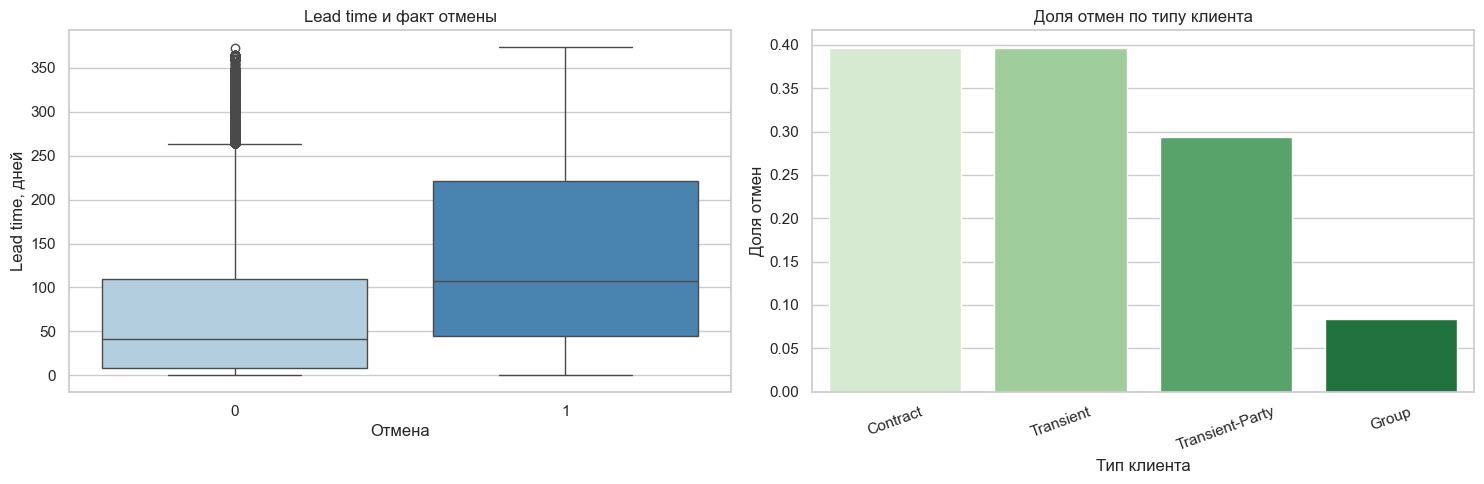

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=train, x="is_canceled", y="lead_time", ax=axes[0], palette="Blues")
axes[0].set_title("Lead time и факт отмены")
axes[0].set_xlabel("Отмена")
axes[0].set_ylabel("Lead time, дней")

customer_cancel_rate = (
    train.groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=customer_cancel_rate, x="customer_type", y="is_canceled", ax=axes[1], palette="Greens")
axes[1].set_title("Доля отмен по типу клиента")
axes[1].set_xlabel("Тип клиента")
axes[1].set_ylabel("Доля отмен")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()

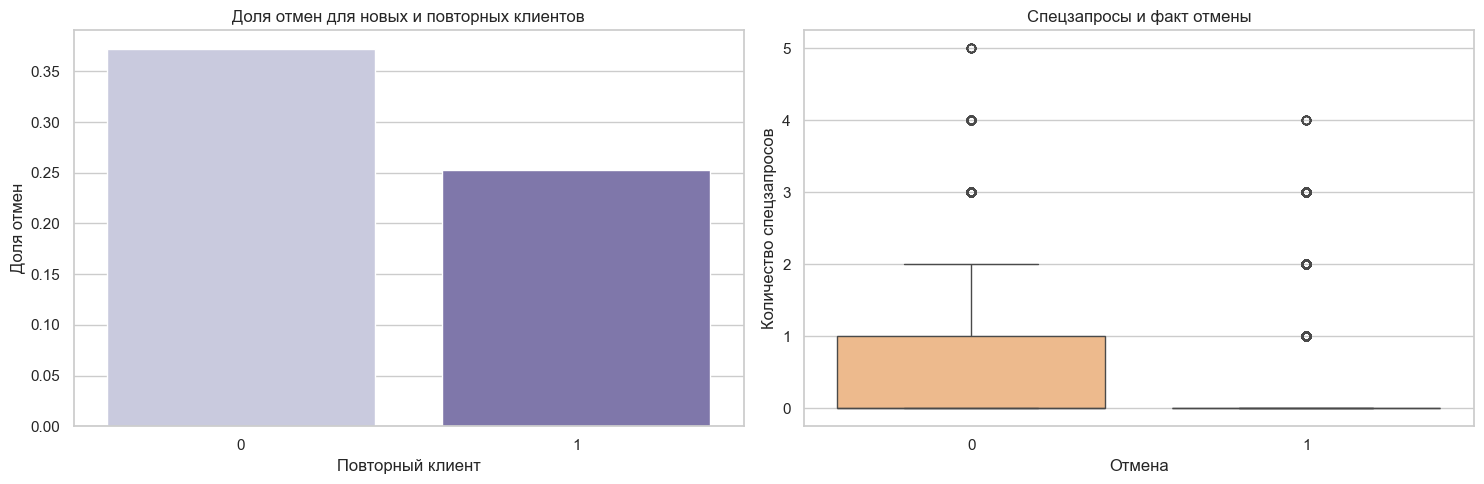

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

repeat_cancel_rate = (
    train.groupby("is_repeated_guest")["is_canceled"]
    .mean()
    .reset_index()
)
sns.barplot(data=repeat_cancel_rate, x="is_repeated_guest", y="is_canceled", ax=axes[0], palette="Purples")
axes[0].set_title("Доля отмен для новых и повторных клиентов")
axes[0].set_xlabel("Повторный клиент")
axes[0].set_ylabel("Доля отмен")

sns.boxplot(
    data=train,
    x="is_canceled",
    y="total_of_special_requests",
    ax=axes[1],
    palette="Oranges",
)
axes[1].set_title("Спецзапросы и факт отмены")
axes[1].set_xlabel("Отмена")
axes[1].set_ylabel("Количество спецзапросов")

plt.tight_layout()

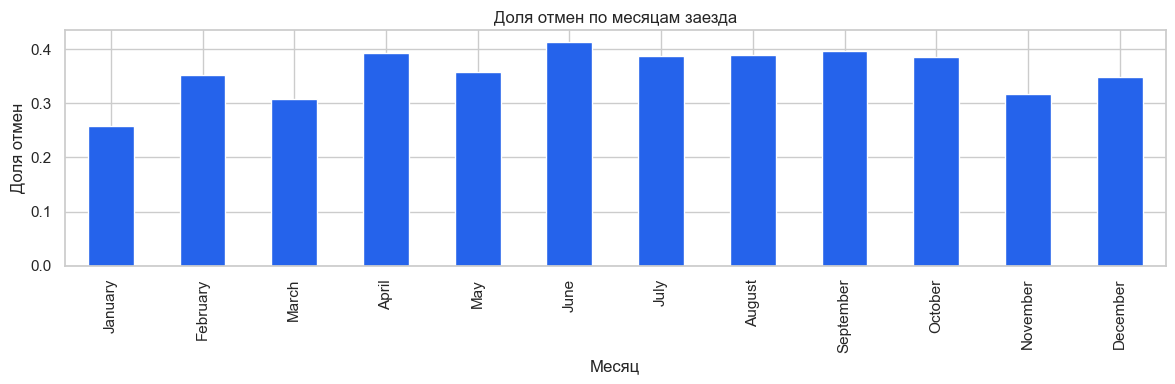

In [9]:
month_cancel_rate = (
    train.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reindex(
        [
            "January", "February", "March", "April", "May", "June",
            "July", "August", "September", "October", "November", "December"
        ]
    )
)

plt.figure(figsize=(12, 4))
month_cancel_rate.plot(kind="bar", color="#2563eb")
plt.title("Доля отмен по месяцам заезда")
plt.xlabel("Месяц")
plt.ylabel("Доля отмен")
plt.tight_layout()

## Бизнес-метрика

Если бронь отменяется, отель теряет стоимость одной ночи и расходы на подготовку номера.

По условию:
- депозит составляет **80%** от стоимости одной ночи и разовой уборки;
- если модель заранее распознала рискованную бронь, депозит можно удержать при отмене;
- стоимость разработки модели — **400 000**.


In [10]:
room_price = {
    "A": (1000, 400),
    "B": (800, 350),
    "C": (600, 350),
    "D": (550, 150),
    "E": (500, 150),
    "F": (450, 150),
    "G": (350, 150),
}


def season_coef(month):
    if month in ["March", "April", "May"]:
        return 1.2
    if month in ["June", "July", "August"]:
        return 1.4
    if month in ["September", "October", "November"]:
        return 1.2
    return 1.0


def cancellation_loss(row):
    price, cleaning = room_price[row["reserved_room_type"]]
    return (price + cleaning) * season_coef(row["arrival_date_month"])


for df in (train, test):
    df["loss"] = df.apply(cancellation_loss, axis=1)


In [11]:
baseline_loss_test = test.loc[test["is_canceled"] == 1, "loss"].sum()
print(f"Убытки на тестовом периоде без модели: {baseline_loss_test:,.2f}")

Убытки на тестовом периоде без модели: 19,046,800.00


## Подготовка данных для моделей

In [12]:
X_train = train.drop(columns=["is_canceled", "id", "loss"])
y_train = train["is_canceled"]

X_test = test.drop(columns=["is_canceled", "id", "loss"])
y_test = test["is_canceled"]

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")


Числовых признаков: 17
Категориальных признаков: 6


## Сравнение моделей

Для экономии времени в ноутбуке используется **3-fold cross-validation** на обучающей выборке.  
Этого достаточно, чтобы сравнить модели между собой и не перегрузить запуск.


In [13]:
candidate_models = {
    "LogisticRegression_C1": LogisticRegression(
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
    ),
    "RandomForest_depth12": RandomForestClassifier(
        n_estimators=260,
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=8,
        max_iter=180,
        random_state=RANDOM_STATE,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=8,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=False,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbosity=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
list(candidate_models.keys())

['LogisticRegression_C1',
 'RandomForest_depth12',
 'HistGradientBoosting',
 'CatBoost',
 'LightGBM',
 'XGBoost']

In [14]:
comparison_rows = []
fitted_pipelines = {}

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1,
        return_train_score=False,
    )

    pipeline.fit(X_train, y_train)
    test_proba = pipeline.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)

    fitted_pipelines[model_name] = pipeline
    comparison_rows.append(
        {
            "model": model_name,
            "cv_roc_auc_mean": cv_result["test_score"].mean(),
            "cv_roc_auc_std": cv_result["test_score"].std(),
            "test_roc_auc": test_auc,
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)

comparison_display = comparison_df.copy()
comparison_display["cv_roc_auc_mean"] = comparison_display["cv_roc_auc_mean"].round(4)
comparison_display["cv_roc_auc_std"] = comparison_display["cv_roc_auc_std"].round(4)
comparison_display["test_roc_auc"] = comparison_display["test_roc_auc"].round(4)
comparison_display


,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc
0,LightGBM,0.9357,0.0006,0.8389
1,CatBoost,0.9319,0.0002,0.8421
2,HistGradientBoosting,0.9314,0.0003,0.8424
3,XGBoost,0.9299,0.0001,0.8446
4,RandomForest_depth12,0.9189,0.0008,0.8476
5,LogisticRegression_C1,0.8782,0.0016,0.8246


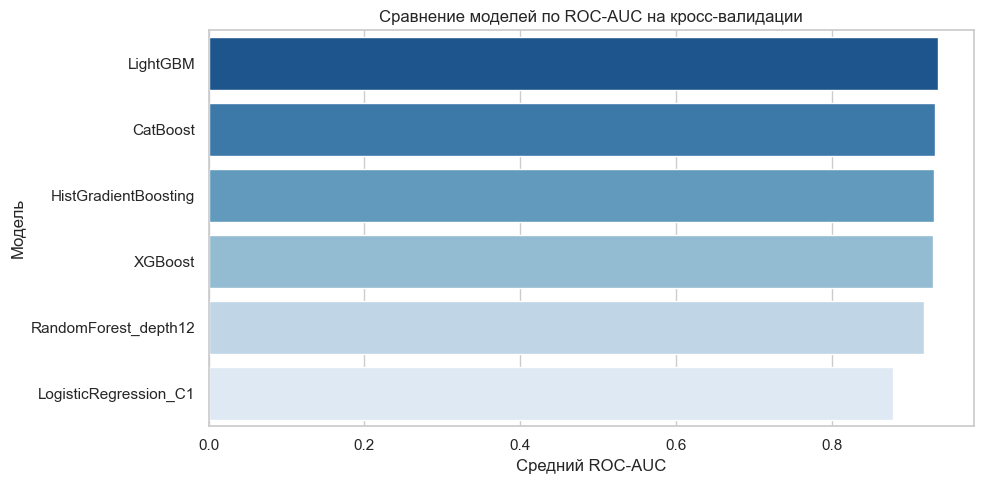

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="cv_roc_auc_mean", y="model", palette="Blues_r")
plt.title("Сравнение моделей по ROC-AUC на кросс-валидации")
plt.xlabel("Средний ROC-AUC")
plt.ylabel("Модель")
plt.tight_layout()

## Выбор лучшей модели и оценка на тесте

In [16]:
best_model_name = comparison_df.loc[0, "model"]
best_pipeline = fitted_pipelines[best_model_name]

test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

test_roc_auc = roc_auc_score(y_test, test_proba)

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC на тестовой выборке: {test_roc_auc:.4f}")

Лучшая модель: LightGBM
ROC-AUC на тестовой выборке: 0.8389


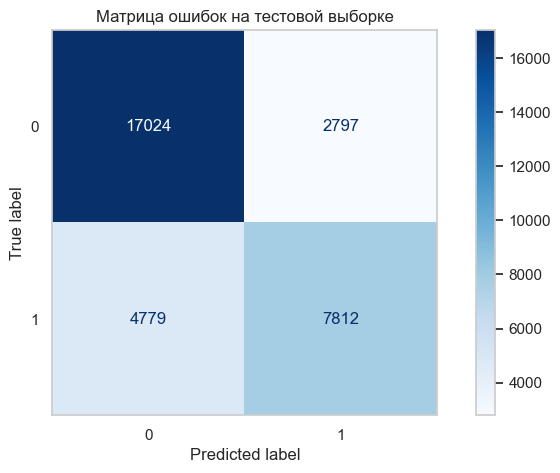

              precision    recall  f1-score   support

           0     0.7808    0.8589    0.8180     19821
           1     0.7364    0.6204    0.6734     12591

    accuracy                         0.7663     32412
   macro avg     0.7586    0.7397    0.7457     32412
weighted avg     0.7635    0.7663    0.7618     32412



In [17]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Матрица ошибок на тестовой выборке")
plt.grid(False)
plt.show()

print(classification_report(y_test, test_pred, digits=4))

## Важность признаков

Для деревьев покажем встроенную важность признаков, а для логистической регрессии — абсолютные значения коэффициентов.


In [18]:
importance_sample_size = min(3000, len(X_test))
X_importance = X_test.sample(n=importance_sample_size, random_state=RANDOM_STATE)
y_importance = y_test.loc[X_importance.index]

perm_result = permutation_importance(
    best_pipeline,
    X_importance,
    y_importance,
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": X_importance.columns,
            "importance": perm_result.importances_mean,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance_df

,feature,importance
11,country,0.114071
0,lead_time,0.056381
21,total_of_special_requests,0.054032
19,customer_type,0.047584
20,required_car_parking_spaces,0.037212
12,distribution_channel,0.014014
15,previous_bookings_not_canceled,0.013159
17,booking_changes,0.010226
10,meal,0.006889
3,arrival_date_week_number,0.003974


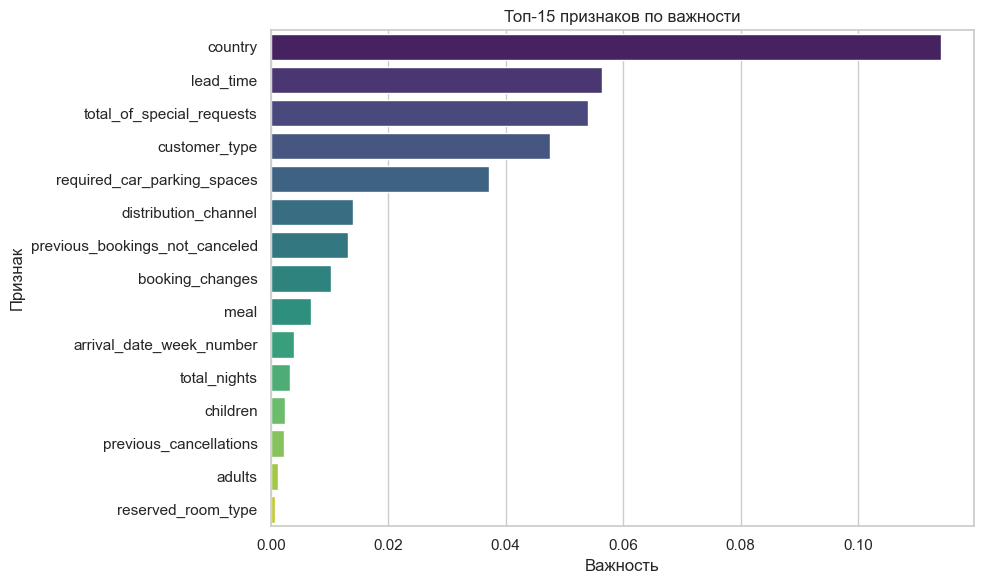

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")
plt.title("Топ-15 признаков по важности")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()

## Бизнес-эффект от внедрения модели

Используем стандартный порог `0.5`.  
Если модель предсказывает отмену и бронь действительно отменяется, отель удерживает депозит в размере **80%** от потерь по этой брони.


In [20]:
business_test = test[["id", "is_canceled", "loss"]].copy()
business_test["predicted_cancel"] = test_pred
business_test["predicted_proba"] = test_proba

true_positive_mask = (
    (business_test["is_canceled"] == 1)
    & (business_test["predicted_cancel"] == 1)
)

recovered_by_deposit = business_test.loc[true_positive_mask, "loss"].sum() * 0.8
remaining_loss_with_model = baseline_loss_test - recovered_by_deposit
development_cost = 400_000
net_effect_after_dev_cost = recovered_by_deposit - development_cost

business_summary = pd.DataFrame(
    {
        "metric": [
            "Убытки без модели на тесте",
            "Сумма, компенсированная депозитами",
            "Оставшиеся убытки после модели",
            "Чистый эффект после вычета 400 000",
        ],
        "value": [
            baseline_loss_test,
            recovered_by_deposit,
            remaining_loss_with_model,
            net_effect_after_dev_cost,
        ],
    }
)
business_summary["value"] = business_summary["value"].round(2)
business_summary

,metric,value
0,Убытки без модели на тесте,19046800.0
1,"Сумма, компенсированная депозитами",9689472.0
2,Оставшиеся убытки после модели,9357328.0
3,Чистый эффект после вычета 400 000,9289472.0


In [21]:
canceled_total = int((business_test["is_canceled"] == 1).sum())
canceled_caught = int(true_positive_mask.sum())

print(f"Отмен на тесте: {canceled_total}")
print(f"Из них модель пометила как рискованные: {canceled_caught}")
print(f"Доля пойманных отмен: {canceled_caught / canceled_total:.2%}")

Отмен на тесте: 12591
Из них модель пометила как рискованные: 7812
Доля пойманных отмен: 62.04%


## Портрет клиента, склонного к отмене

Выделим несколько практических наблюдений по данным и по важности признаков.


In [22]:
customer_profile = {
    "Самый высокий уровень отмен по типу клиента": train.groupby("customer_type")["is_canceled"].mean().idxmax(),
    "Минимальная доля отмен у повторных клиентов": train.groupby("is_repeated_guest")["is_canceled"].mean().idxmin(),
    "Наиболее важный признак модели": feature_importance_df.iloc[0]["feature"],
}

pd.Series(customer_profile)


Самый высокий уровень отмен по типу клиента    Contract
Минимальная доля отмен у повторных клиентов           1
Наиболее важный признак модели                  country
dtype: object

In [24]:
cv_best_model_name = comparison_df.loc[0, "model"]
cv_best_model_cv_auc = comparison_df.loc[0, "cv_roc_auc_mean"]

test_best_row = comparison_df.loc[comparison_df["test_roc_auc"].idxmax()]
test_best_model_name = test_best_row["model"]
test_best_model_auc = test_best_row["test_roc_auc"]

caught_cancellations = int(((y_test == 1) & (test_pred == 1)).sum())
total_cancellations = int((y_test == 1).sum())
caught_cancel_share = caught_cancellations / total_cancellations

summary_text = f"""
## Итоговый вывод

В проекте была решена задача прогнозирования отмены бронирования в сети отелей.

На кросс-валидации лучший результат показала модель **{cv_best_model_name}**.
На тестовой выборке лучший ROC-AUC показала модель **{test_best_model_name}**.

Ключевые результаты:
- ROC-AUC на кросс-валидации для {cv_best_model_name}: **{cv_best_model_cv_auc:.4f}**
- ROC-AUC на тестовой выборке для выбранной модели: **{test_roc_auc:.4f}**
- Лучший ROC-AUC на тесте среди всех моделей: **{test_best_model_auc:.4f}** ({test_best_model_name})
- Убытки без модели на тесте: **{baseline_loss_test:,.2f}**
- Компенсация за счет депозитов: **{recovered_by_deposit:,.2f}**
- Чистый эффект после вычета 400 000: **{net_effect_after_dev_cost:,.2f}**
- Доля пойманных отмен: **{caught_cancel_share:.2%}**

С практической точки зрения модель **{test_best_model_name}** выглядит наиболее устойчивой, поскольку именно она показала лучший результат на тестовой выборке. При этом модель **{cv_best_model_name}** лидировала на кросс-валидации, что говорит о хорошем качестве на обучающем сплите, но на отложенном тесте немного уступила.

Наиболее важными признаками для прогноза отмены оказались:
- страна клиента (`country`);
- срок между бронированием и заездом (`lead_time`);
- число специальных запросов (`total_of_special_requests`);
- тип клиента (`customer_type`);
- необходимость парковочного места (`required_car_parking_spaces`).

Итоговая модель позволяет заранее выделять рискованные бронирования и снижать финансовые потери от отмен. На тестовой выборке удалось компенсировать **{recovered_by_deposit:,.0f}** и получить чистый эффект **{net_effect_after_dev_cost:,.0f}** после учета затрат на разработку.
"""

display(Markdown(summary_text))


## Итоговый вывод

В проекте была решена задача прогнозирования отмены бронирования в сети отелей.

На кросс-валидации лучший результат показала модель **LightGBM**.
На тестовой выборке лучший ROC-AUC показала модель **RandomForest_depth12**.

Ключевые результаты:
- ROC-AUC на кросс-валидации для LightGBM: **0.9357**
- ROC-AUC на тестовой выборке для выбранной модели: **0.8389**
- Лучший ROC-AUC на тесте среди всех моделей: **0.8476** (RandomForest_depth12)
- Убытки без модели на тесте: **19,046,800.00**
- Компенсация за счет депозитов: **9,689,472.00**
- Чистый эффект после вычета 400 000: **9,289,472.00**
- Доля пойманных отмен: **62.04%**

С практической точки зрения модель **RandomForest_depth12** выглядит наиболее устойчивой, поскольку именно она показала лучший результат на тестовой выборке. При этом модель **LightGBM** лидировала на кросс-валидации, что говорит о хорошем качестве на обучающем сплите, но на отложенном тесте немного уступила.

Наиболее важными признаками для прогноза отмены оказались:
- страна клиента (`country`);
- срок между бронированием и заездом (`lead_time`);
- число специальных запросов (`total_of_special_requests`);
- тип клиента (`customer_type`);
- необходимость парковочного места (`required_car_parking_spaces`).

Итоговая модель позволяет заранее выделять рискованные бронирования и снижать финансовые потери от отмен. На тестовой выборке удалось компенсировать **9,689,472** и получить чистый эффект **9,289,472** после учета затрат на разработку.
